In [ ]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False


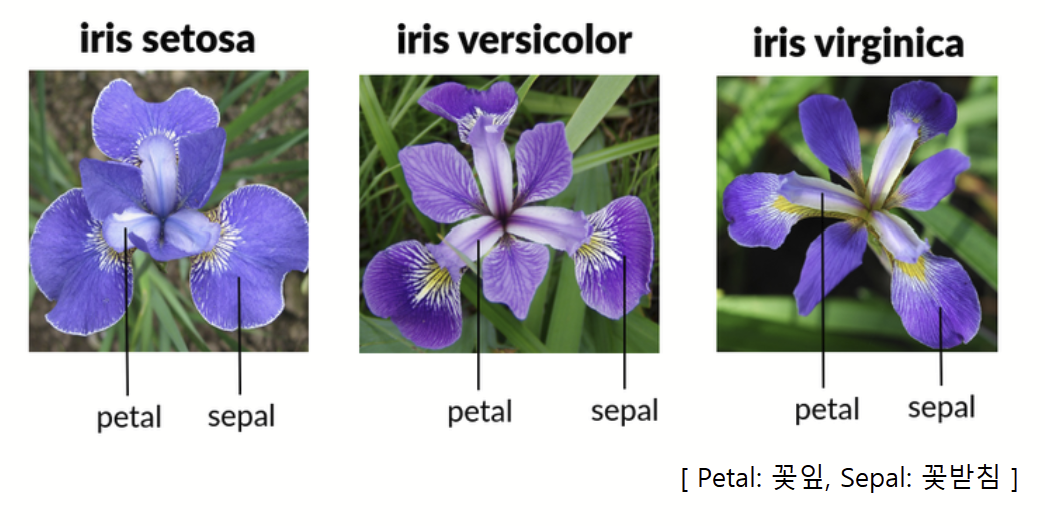

In [ ]:
iris = load_iris(as_frame=True)

In [ ]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
iris['data']

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
iris['target']

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

In [ ]:
iris['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
iris['frame']

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [ ]:
iris['frame'].corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


In [ ]:
x_data = iris['data']
y_data = iris['target']

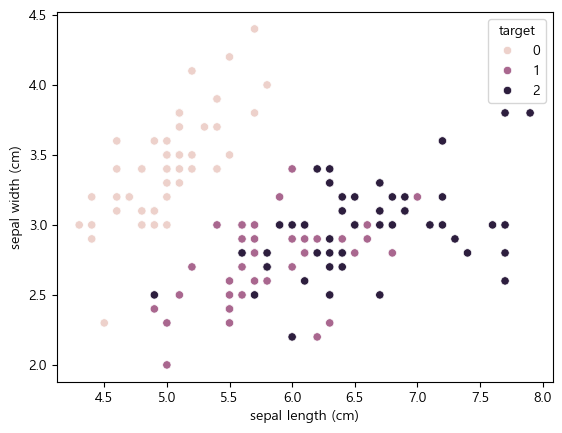

In [ ]:
import seaborn as sb

sb.scatterplot(data=iris['frame'], 
                    x='sepal length (cm)', y= 'sepal width (cm)', hue='target')
plt.show()

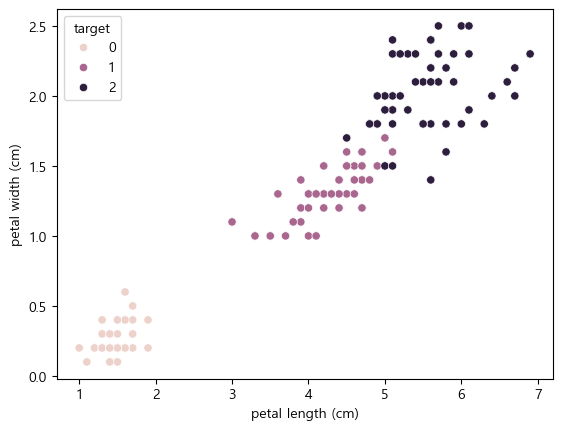

In [ ]:
# 꽃잎을 기준
sb.scatterplot(data=iris['frame'], 
                    x='petal length (cm)', y= 'petal width (cm)', hue='target')
plt.show()

In [ ]:
model = LogisticRegression(max_iter=500)
model.fit(x_data,y_data)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [ ]:
# w: (특성 데이터의 갯수, 라벨(분류)의 갯수)(4,3)
# b: 라벨(분류)의 갯수(3)
model.coef_.T # 사이킬런은 T에서확인하기

array([[-0.4248362 ,  0.53512448, -0.11028828],
       [ 0.96741615, -0.32086871, -0.64654745],
       [-2.51536487, -0.20703587,  2.72240073],
       [-1.08235714, -0.94315282,  2.02550996]])

In [ ]:
model.intercept_

array([  9.85393186,   2.23224793, -12.08617979])

In [ ]:
xd = pd.DataFrame({'sepal length (cm)':[5.1], 'sepal width (cm)':[3.5],
                    'petal length (cm)':[1.4], 'petal width (cm)':[0.2]})
model.predict_proba(xd)

array([[9.81573720e-01, 1.84262658e-02, 1.45025293e-08]])

In [ ]:
pred = model.predict_proba([[5.1, 3.5, 1.4, 0.2]])
# np.argmax(pred , axis=1)
pred.argmax(axis=1)

c:\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [ ]:
# model.predict([[5.1, 3.5, 1.4, 0.2]]) # 데이터프레임 형식으로 값 넣어주기
model.predict(xd) # 0분류

array([0])

In [ ]:
pred = model.predict_proba([[5.1,3.5,1.4,0.2],[6.3,2.5,5.0,1.9]])
pred.argmax(axis=1)

c:\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0, 2])

In [ ]:
def softmax(z):
    e = np.exp(z)
    return e/e.sum()

In [ ]:
# 수동 계산
z = np.matmul([[5.1,3.5,1.4,0.2]], model.coef_.T) + model.intercept_
softmax(z).argmax(axis=1)

array([0])

In [ ]:
## 퀴즈 : 정확도, precision, recall, f1, confusion

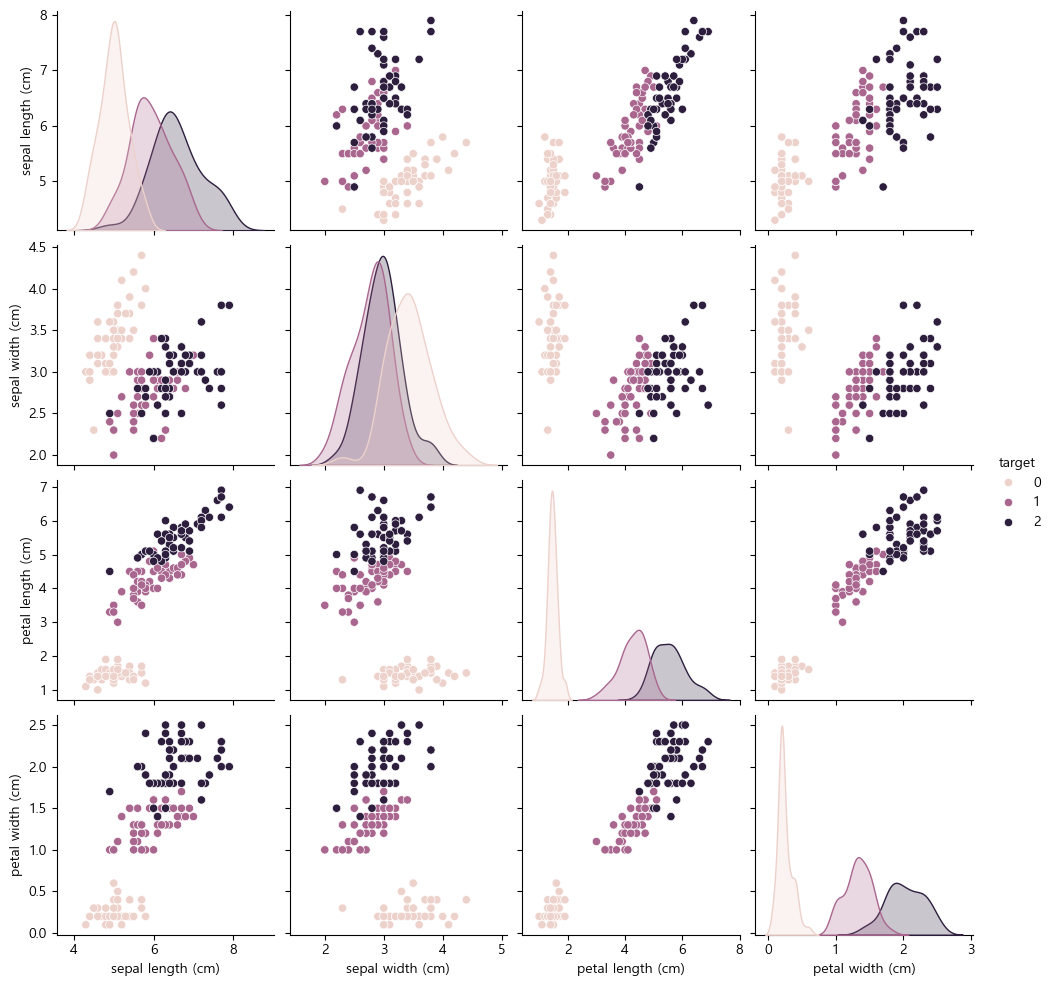

In [ ]:
sb.pairplot(iris['frame'], hue='target')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, confusion_matrix

In [ ]:
pred = model.predict(x_data)
pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
print('정확도', accuracy_score(y_data, pred))
print('정밀도', precision_score(y_data, pred, average='macro'))
print('재현율', recall_score(y_data, pred, average='macro'))
print('f1 score', f1_score(y_data, pred, average='macro'))

# average 옵션 의미
# macro : 클래스별 precision 평균 (동일 가중치) ← 가장 많이 사용
# weighted : 클래스 비율 가중 평균
# micro : 전체 TP/FP 기준 계산
# None : 클래스별 precision을 배열로 반환

정확도 0.9733333333333334
정밀도 0.9738247863247862
재현율 0.9733333333333333
f1 score 0.9733226623982927


In [ ]:
confusion_matrix(y_data, pred)

array([[50,  0,  0],
       [ 0, 47,  3],
       [ 0,  1, 49]])